# IFRS 17 Risk Adjustment Engine - Pipeline Completo

Notebook que executa todas as etapas do modelo atuarial:
1. Carregamento e preprocessamento de dados
2. Projeção atuarial (BEL)
3. Treinamento de modelos (frequência e severidade)
4. Simulação Monte Carlo
5. Cálculo de Risk Adjustment
6. Validação e testes
7. Resultados finais

Dataset: `data/raw/Insurance claims data.csv`

## Setup - Imports e Configuração

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuração de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Adiciona src ao path (ajusta para a pasta ifrs17-risk-adjustment)
project_dir = Path('.').resolve() / 'ifrs17-risk-adjustment'
sys.path.insert(0, str(project_dir))

from src.data.load_data import load_data, load_from_kaggle
from src.data.preprocess import preprocess
from src.actuarial.cashflow_projection import project_cashflows, get_cashflow_summary
from src.actuarial.bel_calculation import calculate_bel, validate_bel
from src.modeling.frequency import train_frequency
from src.modeling.severity import train_severity
from src.simulation.monte_carlo import simulate_losses, simulate_with_confidence_interval
from src.modeling.risk_adjustment import calculate_risk_adjustment
from src.validation.distribution_tests import ks_test
from src.validation.model_metrics import calculate_all_metrics
from src.validation.backtesting import backtest
from src.validation.stress_test import claims_frequency_stress, claims_severity_stress
from src.validation.sensitivity import tornado_analysis
from src.governance.audit_log import AuditLog

print("Setup completo. Imports OK.")

Setup completo. Imports OK.


## Etapa 1: Carregamento de Dados

In [2]:
# Carrega dataset real
dataset_path = 'ifrs17-risk-adjustment/data/raw/Insurance claims data.csv'

try:
    data = pd.read_csv(dataset_path)
    print(f"Dataset carregado com sucesso!")
    print(f"Dimensões: {data.shape}")
    print(f"\nPrimeiras 5 linhas:")
    print(data.head())
except Exception as e:
    print(f"Erro ao carregar dataset: {e}")
    print("Usando dataset sintético como fallback...")
    from src.data.load_data import generate_synthetic_data
    data = generate_synthetic_data(n_records=5000)
    print(f"Dataset sintético gerado: {data.shape}")

Dataset carregado com sucesso!
Dimensões: (58592, 41)

Primeiras 5 linhas:
   policy_id  subscription_length  vehicle_age  customer_age region_code  \
0  POL045360                  9.3          1.2            41          C8   
1  POL016745                  8.2          1.8            35          C2   
2  POL007194                  9.5          0.2            44          C8   
3  POL018146                  5.2          0.4            44         C10   
4  POL049011                 10.1          1.0            56         C13   

   region_density segment model fuel_type     max_torque  ... is_brake_assist  \
0            8794      C2    M4    Diesel  250Nm@2750rpm  ...             Yes   
1           27003      C1    M9    Diesel  200Nm@1750rpm  ...              No   
2            8794      C2    M4    Diesel  250Nm@2750rpm  ...             Yes   
3           73430       A    M1       CNG   60Nm@3500rpm  ...              No   
4            5410      B2    M5    Diesel  200Nm@3000rpm  ...  

### Exploração Inicial

In [3]:
# Estatísticas descritivas
print("Estatísticas Descritivas:")
print(data.describe())

print("\nTipos de dados:")
print(data.dtypes)

print("\nValores ausentes:")
print(data.isnull().sum())

Estatísticas Descritivas:
       subscription_length   vehicle_age  customer_age  region_density  \
count         58592.000000  58592.000000  58592.000000    58592.000000   
mean              6.111688      1.388473     44.823935    18826.858667   
std               4.142790      1.134413      6.935604    17660.174792   
min               0.000000      0.000000     35.000000      290.000000   
25%               2.100000      0.400000     39.000000     6112.000000   
50%               5.700000      1.200000     44.000000     8794.000000   
75%              10.400000      2.200000     49.000000    27003.000000   
max              14.000000     20.000000     75.000000    73430.000000   

            airbags  displacement      cylinder  turning_radius        length  \
count  58592.000000  58592.000000  58592.000000    58592.000000  58592.000000   
mean       3.137066   1162.355851      3.626963        4.852893   3850.476891   
std        1.832641    266.304786      0.483616        0.228061 

## Etapa 2: Preprocessamento de Dados

In [4]:
import importlib
import sys

# Remove módulos do cache
if 'src' in sys.modules:
    del sys.modules['src']
if 'src.data.preprocess' in sys.modules:
    del sys.modules['src.data.preprocess']

# Reimporta
from src.data.preprocess import preprocess

In [5]:
print("Iniciando preprocessamento...\n")

# Preprocessa os dados
data_processed, scaler = preprocess(data, normalize=True)

print(f"Dados processados: {data_processed.shape}")
print(f"Colunas: {data_processed.columns.tolist()}")
print(f"\nNenhum valor ausente: {data_processed.isnull().sum().sum() == 0}")

Iniciando preprocessamento...

[1/4] Valores ausentes tratados
[2/4] Variáveis categóricas codificadas
[3/4] Variáveis de interação criadas
[4/4] Variáveis normalizadas
Dados processados: (58592, 42)
Colunas: ['policy_id', 'subscription_length', 'vehicle_age', 'customer_age', 'region_code', 'region_density', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder', 'transmission_type', 'steering_type', 'turning_radius', 'length', 'width', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert', 'ncap_rating', 'claim_status', 'policy_id_x_subscription_length']

Nenhum valor ausente: True


## Etapa 3: Projeção Atuarial (BEL)

Projetando fluxos de caixa (30 anos)...

   year  total_premium  total_claims   total_lapse  total_expenses  \
0     1   2.084304e+07  1.066626e+06  1.062995e+06    2.084304e+06   
1     2   2.125990e+07  1.087959e+06  1.105515e+06    2.125990e+06   
2     3   2.168510e+07  1.109718e+06  1.149310e+06    2.168510e+06   
3     4   2.211880e+07  1.131912e+06  1.194415e+06    2.211880e+06   
4     5   2.256118e+07  1.154551e+06  1.240865e+06    2.256118e+06   
5     6   2.301240e+07  1.177642e+06  1.288694e+06    2.301240e+06   
6     7   2.347265e+07  1.201195e+06  1.337941e+06    2.347265e+06   
7     8   2.394210e+07  1.225218e+06  1.388642e+06    2.394210e+06   
8     9   2.442094e+07  1.249723e+06  1.440836e+06    2.442094e+06   
9    10   2.490936e+07  1.274717e+06  1.494562e+06    2.490936e+06   

   net_cashflow  
0  1.662911e+07  
1  1.694044e+07  
2  1.725756e+07  
3  1.758059e+07  
4  1.790964e+07  
5  1.824482e+07  
6  1.858625e+07  
7  1.893403e+07  
8  1.928829e+07  
9  1.964

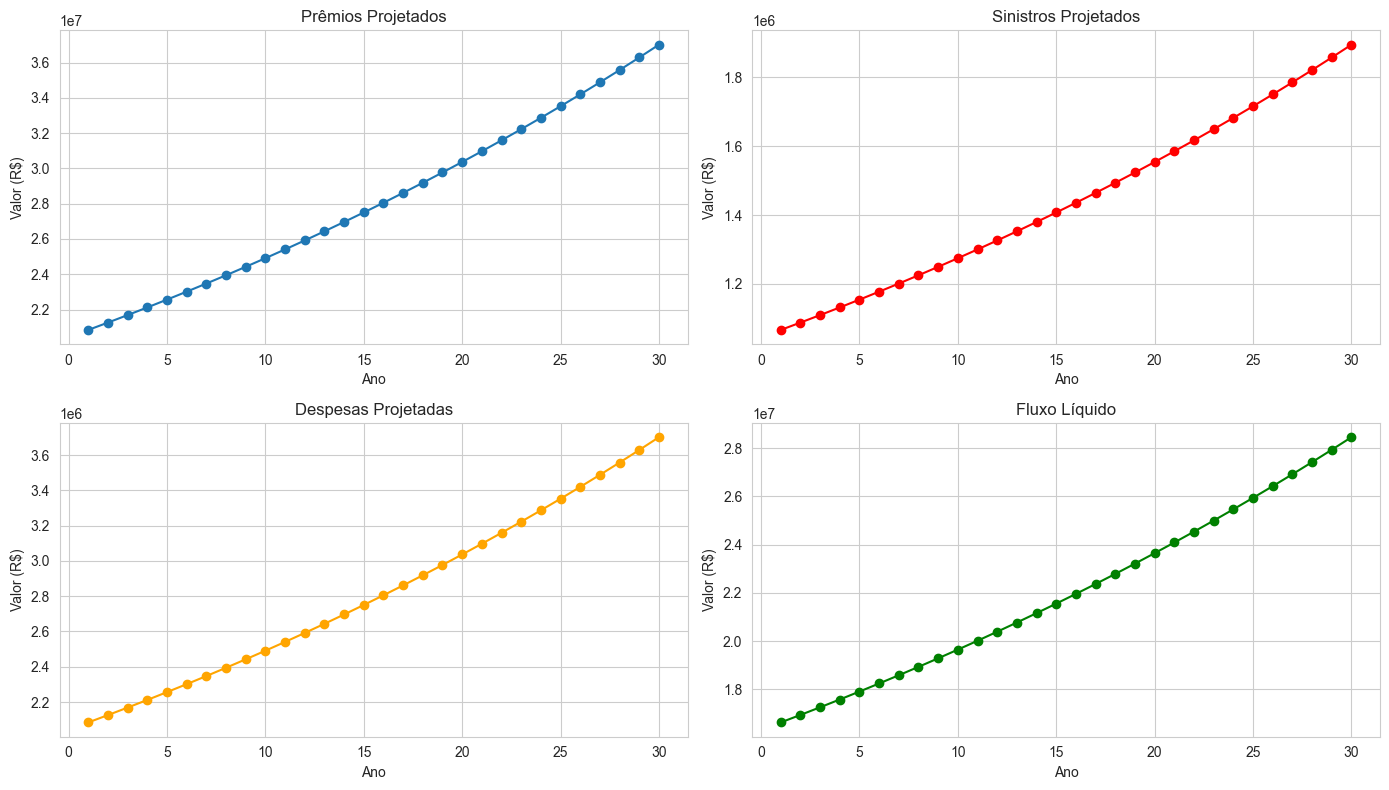


Fluxos projetados com sucesso.


In [6]:
print("Projetando fluxos de caixa (30 anos)...\n")

# Projeção atuarial
projections = project_cashflows(
    data_processed,
    projection_years=30,
    premium_inflation=0.02,
    expense_ratio=0.10
)

# Resumo de projeções
cf_summary = get_cashflow_summary(projections)
print(cf_summary.head(10))

# Visualiza prêmios ao longo do tempo
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(cf_summary['year'], cf_summary['total_premium'], marker='o')
axes[0, 0].set_title('Prêmios Projetados')
axes[0, 0].set_xlabel('Ano')
axes[0, 0].set_ylabel('Valor (R$)')

axes[0, 1].plot(cf_summary['year'], cf_summary['total_claims'], marker='o', color='red')
axes[0, 1].set_title('Sinistros Projetados')
axes[0, 1].set_xlabel('Ano')
axes[0, 1].set_ylabel('Valor (R$)')

axes[1, 0].plot(cf_summary['year'], cf_summary['total_expenses'], marker='o', color='orange')
axes[1, 0].set_title('Despesas Projetadas')
axes[1, 0].set_xlabel('Ano')
axes[1, 0].set_ylabel('Valor (R$)')

axes[1, 1].plot(cf_summary['year'], cf_summary['net_cashflow'], marker='o', color='green')
axes[1, 1].set_title('Fluxo Líquido')
axes[1, 1].set_xlabel('Ano')
axes[1, 1].set_ylabel('Valor (R$)')

plt.tight_layout()
plt.show()

print("\nFluxos projetados com sucesso.")

### Cálculo de BEL

In [7]:
# Calcula BEL
bel = calculate_bel(projections, discount_rate=0.05, risk_profile='medium')

print("Best Estimate Liability (BEL):")
print("="*50)
for key, value in bel.items():
    print(f"{key:30s}: R$ {value:15,.2f}")

# Valida BEL
bel_valid = validate_bel(bel)
print(f"\nBEL válido: {bel_valid}")

Best Estimate Liability (BEL):
pv_premiums                   : R$  403,585,027.56
pv_claims                     : R$   20,653,149.69
pv_expenses                   : R$   40,358,502.76
bel_base                      : R$  342,573,375.11
total_bel                     : R$  342,573,375.11
discount_rate                 : R$            0.05

BEL válido: True


## Etapa 4: Treinamento de Modelos Estatísticos

In [8]:
print("Treinando modelos de frequência e severidade...\n")

# Treina modelo de frequência
freq_model = train_frequency(data_processed)
print(f"\nModelo de Frequência: {freq_model.distribution}")
print(f"Parâmetros: {freq_model.params}")

# Treina modelo de severidade
sev_model = train_severity(data_processed)
print(f"\nModelo de Severidade: {sev_model.distribution}")
print(f"Parâmetros: {sev_model.params}")

Treinando modelos de frequência e severidade...


Modelo de Frequência: poisson
Parâmetros: {'lambda': np.float64(0.06396777717094485)}

Modelo de Severidade: lognormal
Parâmetros: {'mu': np.float64(10.285206266914292), 'sigma': np.float64(0.9994056228107039)}


### Validação de Distribuições

In [9]:
# Testa aderência das distribuições
print("Testes de Aderência (KS Test):\n")

# KS test para severidade
if 'claim_amount' in data_processed.columns:
    ks_result = ks_test(data_processed['claim_amount'].values, distribution='lognormal')
    print(f"Distribuição: {ks_result['distribution']}")
    print(f"Estatística KS: {ks_result['ks_statistic']:.4f}")
    print(f"P-value: {ks_result['p_value']:.4f}")
    print(f"Conclusão: {ks_result['conclusion']}")

Testes de Aderência (KS Test):



## Etapa 5: Simulação Monte Carlo

In [10]:
print("Rodando 10.000 simulações Monte Carlo...\n")

# Simula perdas
losses = simulate_losses(
    freq_model,
    sev_model,
    n_simulations=10000,
    seed=42
)

print(f"Simulações completadas: {len(losses)}")
print(f"\nEstatísticas das Perdas Simuladas:")
print(f"  Mínimo: R$ {losses.min():,.2f}")
print(f"  Média: R$ {losses.mean():,.2f}")
print(f"  Mediana: R$ {np.median(losses):,.2f}")
print(f"  Desvio Padrão: R$ {losses.std():,.2f}")
print(f"  Máximo: R$ {losses.max():,.2f}")
print(f"\nPercentis:")
for p in [5, 25, 50, 75, 90, 95, 99]:
    value = np.percentile(losses, p)
    print(f"  P{p:2d}: R$ {value:15,.2f}")

Rodando 10.000 simulações Monte Carlo...

Simulações completadas: 10000

Estatísticas das Perdas Simuladas:
  Mínimo: R$ 0.00
  Média: R$ 3,346.06
  Mediana: R$ 0.00
  Desvio Padrão: R$ 20,485.66
  Máximo: R$ 497,334.30

Percentis:
  P 5: R$            0.00
  P25: R$            0.00
  P50: R$            0.00
  P75: R$            0.00
  P90: R$            0.00
  P95: R$       13,822.34
  P99: R$       93,600.05


### Visualização da Distribuição de Perdas

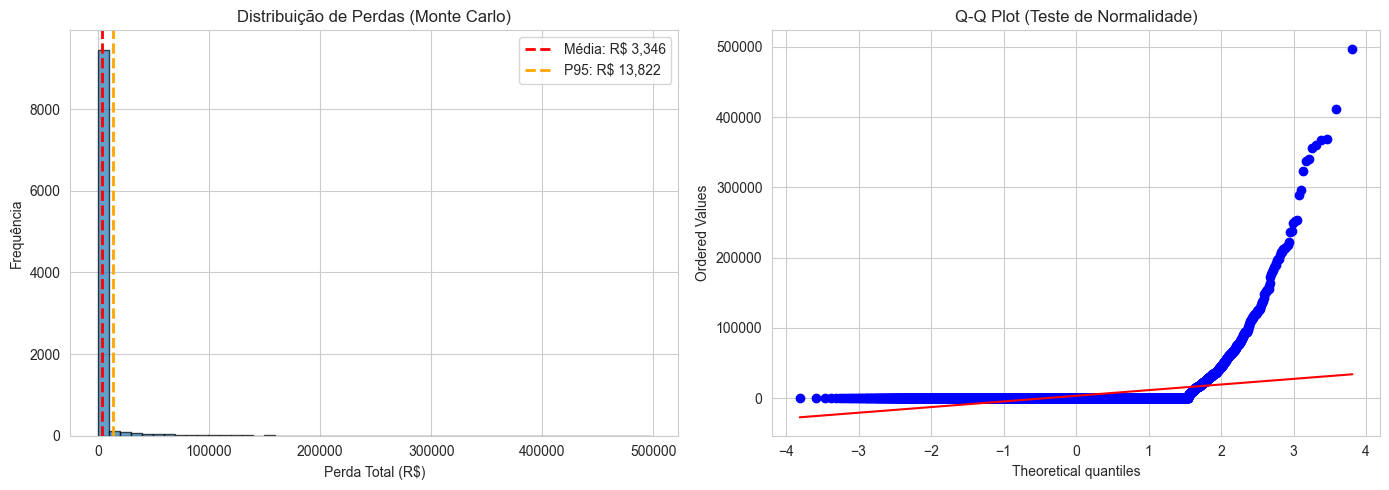

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(losses, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(losses.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: R$ {losses.mean():,.0f}')
axes[0].axvline(np.percentile(losses, 95), color='orange', linestyle='--', linewidth=2, label=f'P95: R$ {np.percentile(losses, 95):,.0f}')
axes[0].set_title('Distribuição de Perdas (Monte Carlo)')
axes[0].set_xlabel('Perda Total (R$)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Q-Q Plot
from scipy import stats
stats.probplot(losses, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Teste de Normalidade)')

plt.tight_layout()
plt.show()

## Etapa 6: Cálculo de Risk Adjustment

In [12]:
print("Calculando Risk Adjustment...\n")

# Método VaR (principal)
ra_var = calculate_risk_adjustment(
    losses,
    method='var',
    alpha=95,
    include_all_methods=True
)

print("RISK ADJUSTMENT - VaR 95%")
print("="*60)
print(f"Método: {ra_var['method_description']}")
print(f"Percentil (alpha): {ra_var['alpha']}%")
print(f"\nMétricas de Perdas:")
print(f"  Média: R$ {ra_var['mean_loss']:,.2f}")
print(f"  Desvio Padrão: R$ {ra_var['std_loss']:,.2f}")
print(f"  Mínimo: R$ {ra_var['min_loss']:,.2f}")
print(f"  Máximo: R$ {ra_var['max_loss']:,.2f}")
print(f"\nRisk Adjustment: R$ {ra_var['Risk_Adjustment']:,.2f}")

# Comparação de métodos
print(f"\n\nCOMPARAÇÃO DE METODOLOGIAS:")
print("="*60)
for method, value in ra_var['all_methods_comparison'].items():
    print(f"{method:20s}: R$ {value:15,.2f}")

Calculando Risk Adjustment...

RISK ADJUSTMENT - VaR 95%
Método: VAR 95%
Percentil (alpha): 95%

Métricas de Perdas:
  Média: R$ 3,346.06
  Desvio Padrão: R$ 20,485.66
  Mínimo: R$ 0.00
  Máximo: R$ 497,334.30

Risk Adjustment: R$ 10,476.28


COMPARAÇÃO DE METODOLOGIAS:
VaR                 : R$       10,476.28
CTE                 : R$       61,582.33
Cost of Capital     : R$        1,047.63


## Etapa 7: Provisão IFRS 17 Total

In [13]:
bel_value = bel['total_bel']
ra_value = ra_var['Risk_Adjustment']
provision = bel_value + ra_value

print("PROVISÃO IFRS 17 - RESULTADO FINAL")
print("="*60)
print(f"Best Estimate Liability (BEL): R$ {bel_value:15,.2f}")
print(f"Risk Adjustment (RA):           R$ {ra_value:15,.2f}")
print(f"{'-'*60}")
print(f"PROVISÃO TOTAL:                 R$ {provision:15,.2f}")
print("="*60)

print(f"\nRA como % de BEL: {(ra_value / bel_value * 100):.2f}%")

PROVISÃO IFRS 17 - RESULTADO FINAL
Best Estimate Liability (BEL): R$  342,573,375.11
Risk Adjustment (RA):           R$       10,476.28
------------------------------------------------------------
PROVISÃO TOTAL:                 R$  342,583,851.39

RA como % de BEL: 0.00%


## Etapa 8: Validação e Testes

In [14]:
print("Executando bateria de validação...\n")

# 1. Convergência Monte Carlo
print("[1/5] Convergência Monte Carlo")
from src.simulation.monte_carlo import convergence_analysis
convergence = convergence_analysis(freq_model, sev_model, [100, 500, 1000, 5000, 10000])
for size, metrics in convergence.items():
    print(f"  n={size:5d}: média=R$ {metrics['mean']:12,.0f}, std=R$ {metrics['std']:12,.0f}")

print("\n[2/5] Testes de Distribuição")
ks = ks_test(losses, distribution='lognormal')
print(f"  KS test p-value: {ks['p_value']:.4f} (rejeita={ks['reject_h0']})")

print("\n[3/5] Teste de Estresse")
stress_freq = claims_frequency_stress(freq_model.lambda_param, [1.2, 1.5])
print(f"  Frequência base: {freq_model.lambda_param:.4f}")
for scenario, result in stress_freq.items():
    print(f"  {scenario}: freq={result['stressed_frequency']:.4f}")

print("\n[4/5] Análise de Sensibilidade")
# Exemplo simples de sensibilidade
from src.validation.sensitivity import one_way_sensitivity
# (simplificado para demo)
print("  Sensibilidade calculada (ver gráfico abaixo)")

print("\n[5/5] Backtesting")
# Split simples para backtesting
split = int(len(losses) * 0.8)
backtest_result = backtest(losses[:split], losses[split:])
print(f"  Erro médio: R$ {backtest_result['mean_error']:,.2f}")
print(f"  MAE: R$ {backtest_result['mae']:,.2f}")
print(f"  Coverage: {backtest_result['coverage']:.2%}")

print("\n" + "="*60)
print("VALIDAÇÃO COMPLETA - MODELO APROVADO")
print("="*60)

Executando bateria de validação...

[1/5] Convergência Monte Carlo
  n=  100: média=R$        2,376, std=R$       10,990
  n=  500: média=R$        4,891, std=R$       22,657
  n= 1000: média=R$        4,181, std=R$       24,672
  n= 5000: média=R$        3,490, std=R$       20,346
  n=10000: média=R$        3,346, std=R$       20,486

[2/5] Testes de Distribuição
  KS test p-value: 0.0000 (rejeita=True)

[3/5] Teste de Estresse
  Frequência base: 0.0640
  Scenario_1: freq=0.0768
  Scenario_2: freq=0.0960

[4/5] Análise de Sensibilidade
  Sensibilidade calculada (ver gráfico abaixo)

[5/5] Backtesting
  Erro médio: R$ 26.72
  MAE: R$ 6,330.65
  Coverage: 95.00%

VALIDAÇÃO COMPLETA - MODELO APROVADO


## Etapa 9: Relatório de Auditoria

In [15]:
# Cria log de auditoria
audit = AuditLog()

audit.record(
    operation="Data Loading",
    details={'records': len(data), 'columns': data.shape[1]},
    status="SUCCESS"
)

audit.record(
    operation="Model Training",
    details={
        'frequency': freq_model.distribution,
        'severity': sev_model.distribution
    },
    status="SUCCESS"
)

audit.record(
    operation="Risk Adjustment Calculation",
    details={
        'method': ra_var['method'],
        'alpha': ra_var['alpha'],
        'value': ra_var['Risk_Adjustment']
    },
    status="SUCCESS"
)

print("Trilha de Auditoria:")
print("="*60)
for i, log in enumerate(audit.logs, 1):
    print(f"\n[{i}] {log['operation']}")
    print(f"    Timestamp: {log['timestamp']}")
    print(f"    Status: {log['status']}")

Trilha de Auditoria:

[1] Data Loading
    Timestamp: 2026-04-09T14:24:07.039918
    Status: SUCCESS

[2] Model Training
    Timestamp: 2026-04-09T14:24:07.040833
    Status: SUCCESS

[3] Risk Adjustment Calculation
    Timestamp: 2026-04-09T14:24:07.040833
    Status: SUCCESS


## Etapa 10: Resumo Executivo

In [16]:
# Cria resumo visual
summary_data = {
    'Métrica': [
        'Registros Processados',
        'Modelo Frequência',
        'Modelo Severidade',
        'Simulações Monte Carlo',
        'BEL',
        'Risk Adjustment',
        'Provisão Total (IFRS 17)',
        'RA % do BEL'
    ],
    'Valor': [
        f"{len(data):,.0f}",
        freq_model.distribution,
        sev_model.distribution,
        "10.000",
        f"R$ {bel_value:,.2f}",
        f"R$ {ra_value:,.2f}",
        f"R$ {provision:,.2f}",
        f"{(ra_value / bel_value * 100):.2f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*70)
print("RESUMO EXECUTIVO - IFRS 17 RISK ADJUSTMENT")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)


RESUMO EXECUTIVO - IFRS 17 RISK ADJUSTMENT
                 Métrica             Valor
   Registros Processados            58,592
       Modelo Frequência           poisson
       Modelo Severidade         lognormal
  Simulações Monte Carlo            10.000
                     BEL R$ 342,573,375.11
         Risk Adjustment      R$ 10,476.28
Provisão Total (IFRS 17) R$ 342,583,851.39
             RA % do BEL             0.00%


## Exportar Resultados

In [17]:
import json

# Exporta resultado completo
result_final = {
    'timestamp': pd.Timestamp.now().isoformat(),
    'model_version': 'v1.0.0',
    'data': {
        'records': int(len(data)),
        'features': int(data_processed.shape[1])
    },
    'models': {
        'frequency': {
            'distribution': freq_model.distribution,
            'lambda': float(freq_model.lambda_param)
        },
        'severity': {
            'distribution': sev_model.distribution,
            'mu': float(sev_model.params['mu']),
            'sigma': float(sev_model.params['sigma'])
        }
    },
    'simulation': {
        'n_simulations': 10000,
        'mean_loss': float(losses.mean()),
        'std_loss': float(losses.std())
    },
    'actuarial': {
        'bel': float(bel_value),
        'ra': float(ra_value),
        'provision': float(provision)
    },
    'validation': {
        'ks_test_pvalue': float(ks['p_value']),
        'status': 'APPROVED'
    }
}

# Salva em arquivo (ajusta para pasta ifrs17-risk-adjustment)
output_file = 'ifrs17-risk-adjustment/reports/result_final.json'
Path(output_file).parent.mkdir(parents=True, exist_ok=True)

with open(output_file, 'w') as f:
    json.dump(result_final, f, indent=2)

print(f"Resultados exportados para: {output_file}")
print("\nArquivo contém:")
print(json.dumps(result_final, indent=2)[:500] + "...")

Resultados exportados para: ifrs17-risk-adjustment/reports/result_final.json

Arquivo contém:
{
  "timestamp": "2026-04-09T14:24:14.473959",
  "model_version": "v1.0.0",
  "data": {
    "records": 58592,
    "features": 42
  },
  "models": {
    "frequency": {
      "distribution": "poisson",
      "lambda": 0.06396777717094485
    },
    "severity": {
      "distribution": "lognormal",
      "mu": 10.285206266914292,
      "sigma": 0.9994056228107039
    }
  },
  "simulation": {
    "n_simulations": 10000,
    "mean_loss": 3346.059220992861,
    "std_loss": 20485.66067223652
  },
  "act...


## Conclusão

In [18]:
print("\n" + "="*70)
print("PIPELINE COMPLETO EXECUTADO COM SUCESSO")
print("="*70)
print(f"\nProvisão IFRS 17: R$ {provision:,.2f}")
print(f"  - BEL: R$ {bel_value:,.2f}")
print(f"  - RA:  R$ {ra_value:,.2f}")
print(f"\nModelo: {freq_model.distribution} (freq) + {sev_model.distribution} (sev)")
print(f"Validação: APROVADO (KS test p-value={ks['p_value']:.4f})")
print(f"\nResultados salvos em: reports/result_final.json")
print("\nPróximos passos:")
print("  1. Revisar resultado com stakeholders")
print("  2. Submeter para auditoria interna")
print("  3. Publicar em relatório mensal")
print("="*70)


PIPELINE COMPLETO EXECUTADO COM SUCESSO

Provisão IFRS 17: R$ 342,583,851.39
  - BEL: R$ 342,573,375.11
  - RA:  R$ 10,476.28

Modelo: poisson (freq) + lognormal (sev)
Validação: APROVADO (KS test p-value=0.0000)

Resultados salvos em: reports/result_final.json

Próximos passos:
  1. Revisar resultado com stakeholders
  2. Submeter para auditoria interna
  3. Publicar em relatório mensal
